# Input Pipeline Visualization

End-to-end visualization of every stage from raw TFRecord to what the model actually sees:
1. **Raw parsed data** — mz/intensity after TFRecord parsing
2. **Filtering & normalization** — peak range filtering, top-k, neutral loss, normalization
3. **Valid mask & padding** — which peaks are real vs zero-padded
4. **Multi-crop augmentation** — 2 global views (80% peaks) + 6 local views (25% peaks) with jitter
5. **Fused batch** — the [V*B, N] tensors the encoder actually receives
6. **Fourier features** — what mz looks like after NeRF-style encoding

In [1]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import torch

# Project imports
from input_pipeline import TfLightningDataModule, numpy_batch_to_torch, _NUM_PEAKS_OUTPUT
from configs.gems_a_50_mask import get_config

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

cfg = get_config()
cfg.tfrecord_dir = "/home/wuhao/spectra-learning/data/gems_peaklist_tfrecord"
dm = TfLightningDataModule(cfg, seed=42)
print(f"Train size: {dm.info['train_size']:,}")
print(f"Val size: {dm.info['validation_size']:,}")
print(f"Num peaks (output): {dm.info['num_peaks']}")
print(f"MZ representation: {dm.info['mz_representation']}")
print(f"Peak ordering: {cfg.peak_ordering}")

Train size: 39,854,312
Val size: 2,097,596
Num peaks (output): 60
MZ representation: mz
Peak ordering: mz


## 1. Raw Batch (Pre-Augmentation)

After TFRecord parsing, filtering, top-k selection, neutral-loss conversion, sorting, and normalization — but **before** two-view augmentation. This is what `_batched_parse_and_transform` produces.

In [2]:
# Build a dataset WITHOUT augmentation to see the raw parsed output
from input_pipeline import _build_dataset

raw_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=1000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    augmentation_type="none",
    peak_ordering=cfg.peak_ordering,
)

raw_batch = next(raw_ds.as_numpy_iterator())
print("Raw batch keys:", list(raw_batch.keys()))
for k, v in raw_batch.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}, range=[{v.min():.4f}, {v.max():.4f}]")

Raw batch keys: ['peak_mz', 'peak_intensity', 'peak_valid_mask', 'precursor_mz', 'rt', 'mz', 'intensity']
  peak_mz: shape=(16, 60), dtype=float32, range=[0.0000, 0.5956]
  peak_intensity: shape=(16, 60), dtype=float32, range=[0.0000, 1.0000]
  peak_valid_mask: shape=(16, 60), dtype=bool, range=[0.0000, 1.0000]
  precursor_mz: shape=(16,), dtype=float32, range=[0.1140, 0.7986]
  rt: shape=(16,), dtype=float32, range=[14.6945, 717.8347]
  mz: shape=(16, 60), dtype=float32, range=[0.0000, 595.5851]
  intensity: shape=(16, 60), dtype=float32, range=[0.0000, 1.0000]


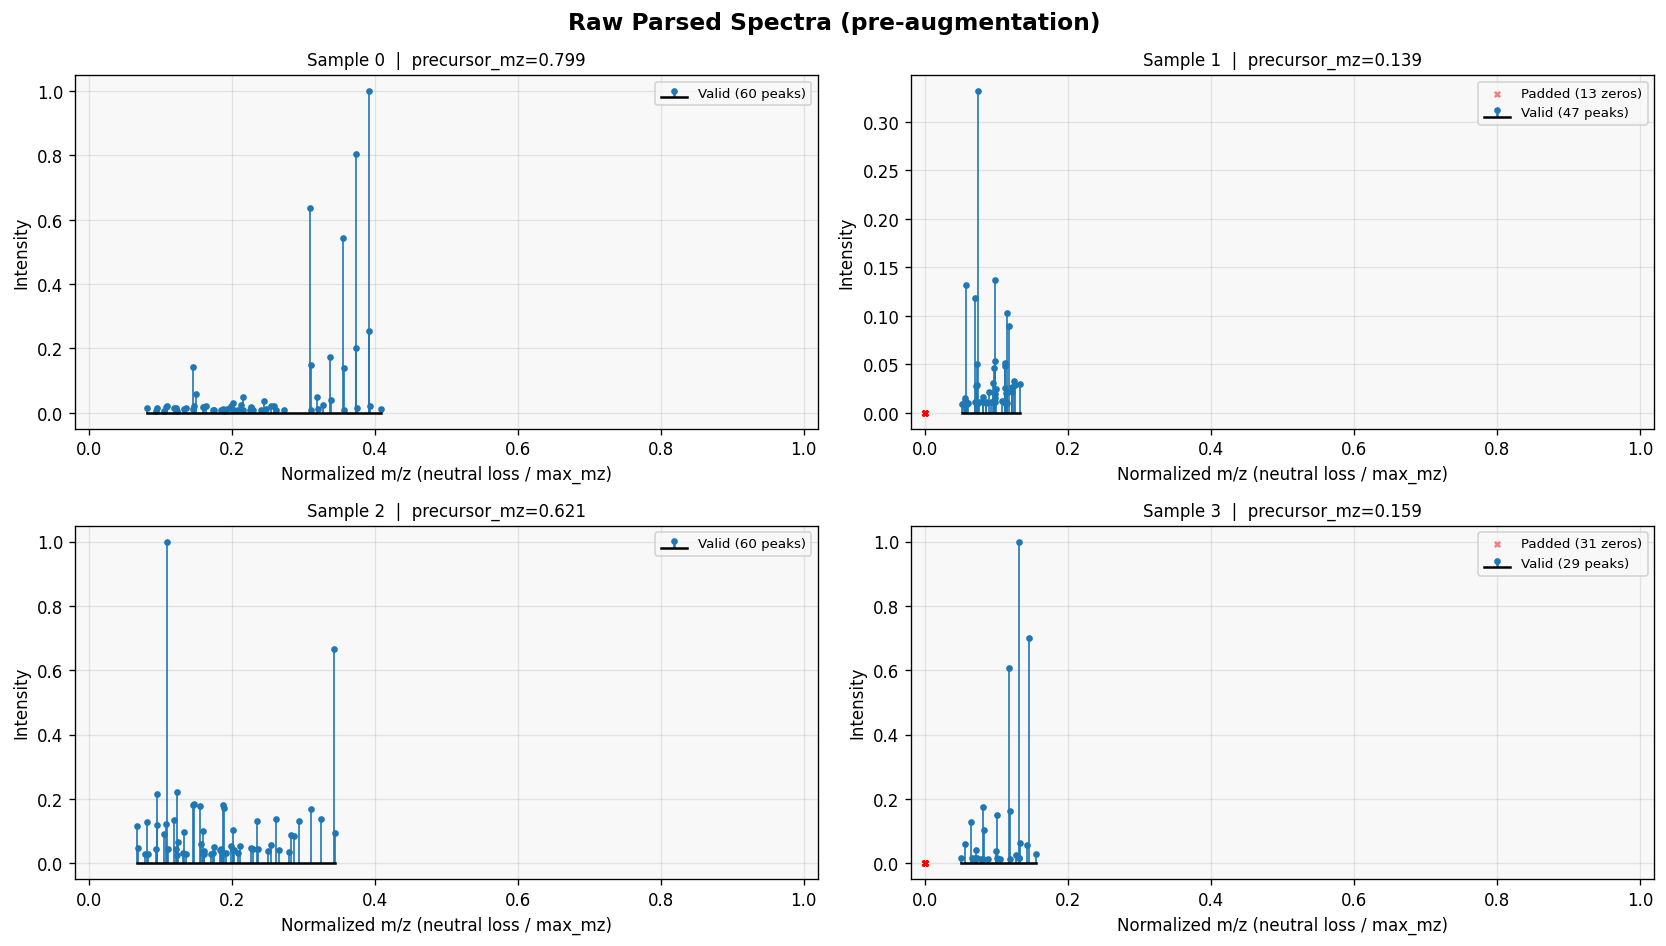

In [3]:
# Visualize 4 raw spectra: stem plots of mz vs intensity with valid mask overlay
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Raw Parsed Spectra (pre-augmentation)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    mz = raw_batch['peak_mz'][idx]       # normalized [0,1]
    intensity = raw_batch['peak_intensity'][idx]
    valid = raw_batch['peak_valid_mask'][idx]
    prec = raw_batch['precursor_mz'][idx]
    
    # Valid peaks
    v_idx = np.where(valid)[0]
    p_idx = np.where(~valid)[0]
    
    markerline, stemlines, baseline = ax.stem(
        mz[v_idx], intensity[v_idx],
        linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=f'Valid ({len(v_idx)} peaks)',
    )
    stemlines.set_linewidth(1.0)
    markerline.set_markersize(3)
    
    if len(p_idx) > 0:
        ax.scatter(mz[p_idx], intensity[p_idx], c='red', s=10, marker='x',
                   alpha=0.5, label=f'Padded ({len(p_idx)} zeros)', zorder=5)
    
    ax.set_title(f'Sample {idx}  |  precursor_mz={prec:.3f}', fontsize=10)
    ax.set_xlabel('Normalized m/z (neutral loss / max_mz)')
    ax.set_ylabel('Intensity')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('notebooks/fig_raw_spectra.png', bbox_inches='tight')
plt.show()

## 2. Valid Mask & Padding Distribution

How many of the 60 peak slots are actually filled vs zero-padded across the batch?

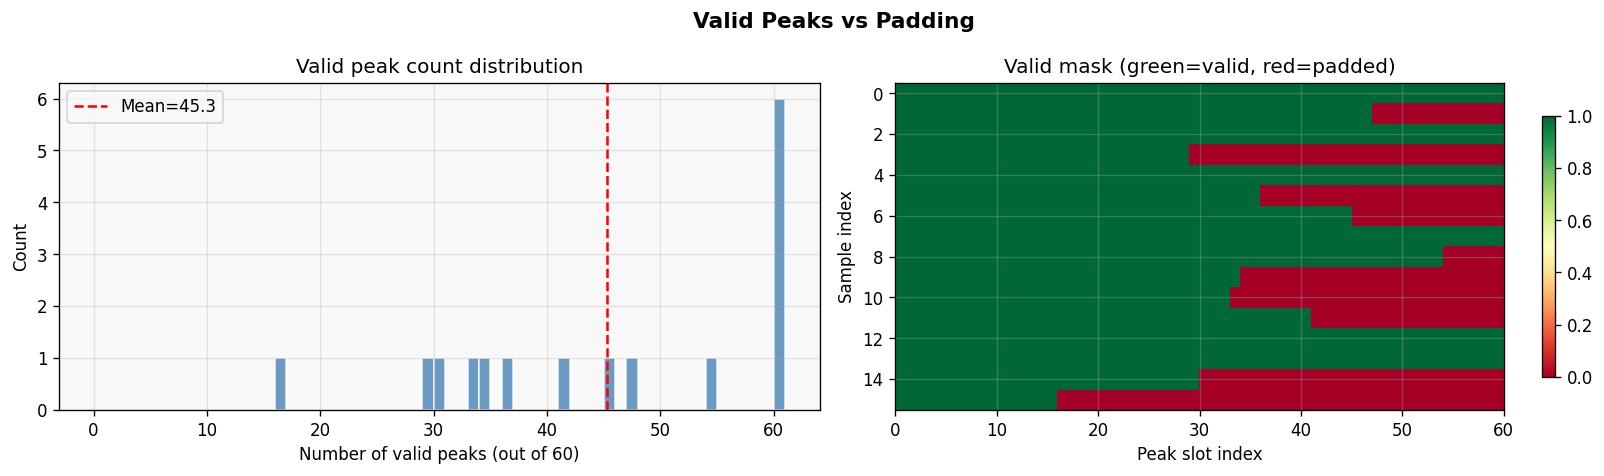

In [4]:
valid_counts = raw_batch['peak_valid_mask'].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Valid Peaks vs Padding', fontsize=13, fontweight='bold')

# Histogram of valid peak counts
ax = axes[0]
ax.hist(valid_counts, bins=range(0, _NUM_PEAKS_OUTPUT + 2), color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(valid_counts.mean(), color='red', ls='--', label=f'Mean={valid_counts.mean():.1f}')
ax.set_xlabel('Number of valid peaks (out of 60)')
ax.set_ylabel('Count')
ax.set_title('Valid peak count distribution')
ax.legend()

# Heatmap: each row is a sample, columns are peak slots, color = valid/padded
ax = axes[1]
im = ax.imshow(raw_batch['peak_valid_mask'][:16].astype(float),
               aspect='auto', cmap='RdYlGn', interpolation='nearest',
               extent=[0, _NUM_PEAKS_OUTPUT, 15.5, -0.5])
ax.set_xlabel('Peak slot index')
ax.set_ylabel('Sample index')
ax.set_title('Valid mask (green=valid, red=padded)')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('notebooks/fig_valid_mask.png', bbox_inches='tight')
plt.show()

## 3. Multi-Crop Augmentation

Apply multi-crop augmentation: 2 global views (keep 80% of peaks) + 6 local views (keep 25% of peaks), each with jitter. The fused tensors are `[V*B, N]` where V = num_global + num_local.

In [5]:
# Build dataset WITH multicrop augmentation
aug_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=1000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    augmentation_type="multicrop",
    multicrop_num_global_views=cfg.multicrop_num_global_views,
    multicrop_num_local_views=cfg.multicrop_num_local_views,
    multicrop_global_keep_fraction=cfg.multicrop_global_keep_fraction,
    multicrop_local_keep_fraction=cfg.multicrop_local_keep_fraction,
    mz_jitter_std=cfg.sigreg_mz_jitter_std,
    intensity_jitter_std=cfg.sigreg_intensity_jitter_std,
    peak_ordering=cfg.peak_ordering,
)

aug_batch = next(aug_ds.as_numpy_iterator())
print("Augmented batch keys:", list(aug_batch.keys()))

V = cfg.multicrop_num_global_views + cfg.multicrop_num_local_views
B = 16
print(f"\nV={V} views (global={cfg.multicrop_num_global_views}, local={cfg.multicrop_num_local_views})")
print(f"Fused tensors are [V*B, N] = [{aug_batch['fused_mz'].shape[0]}, {aug_batch['fused_mz'].shape[1]}]")
for k in ['fused_mz', 'fused_intensity', 'fused_valid_mask', 'fused_precursor_mz']:
    v = aug_batch[k]
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

print(f"\nEncoder-visible fraction (fused_valid_mask): {aug_batch['fused_valid_mask'].mean():.3f}")

Augmented batch keys: ['peak_mz', 'peak_intensity', 'peak_valid_mask', 'precursor_mz', 'rt', 'mz', 'intensity', 'fused_mz', 'fused_intensity', 'fused_precursor_mz', 'fused_valid_mask']

V=6 views (global=2, local=4)
Fused tensors are [V*B, N] = [96, 60]
  fused_mz: shape=(96, 60), dtype=float32
  fused_intensity: shape=(96, 60), dtype=float32
  fused_valid_mask: shape=(96, 60), dtype=bool
  fused_precursor_mz: shape=(96,), dtype=float32

Encoder-visible fraction (fused_valid_mask): 0.327


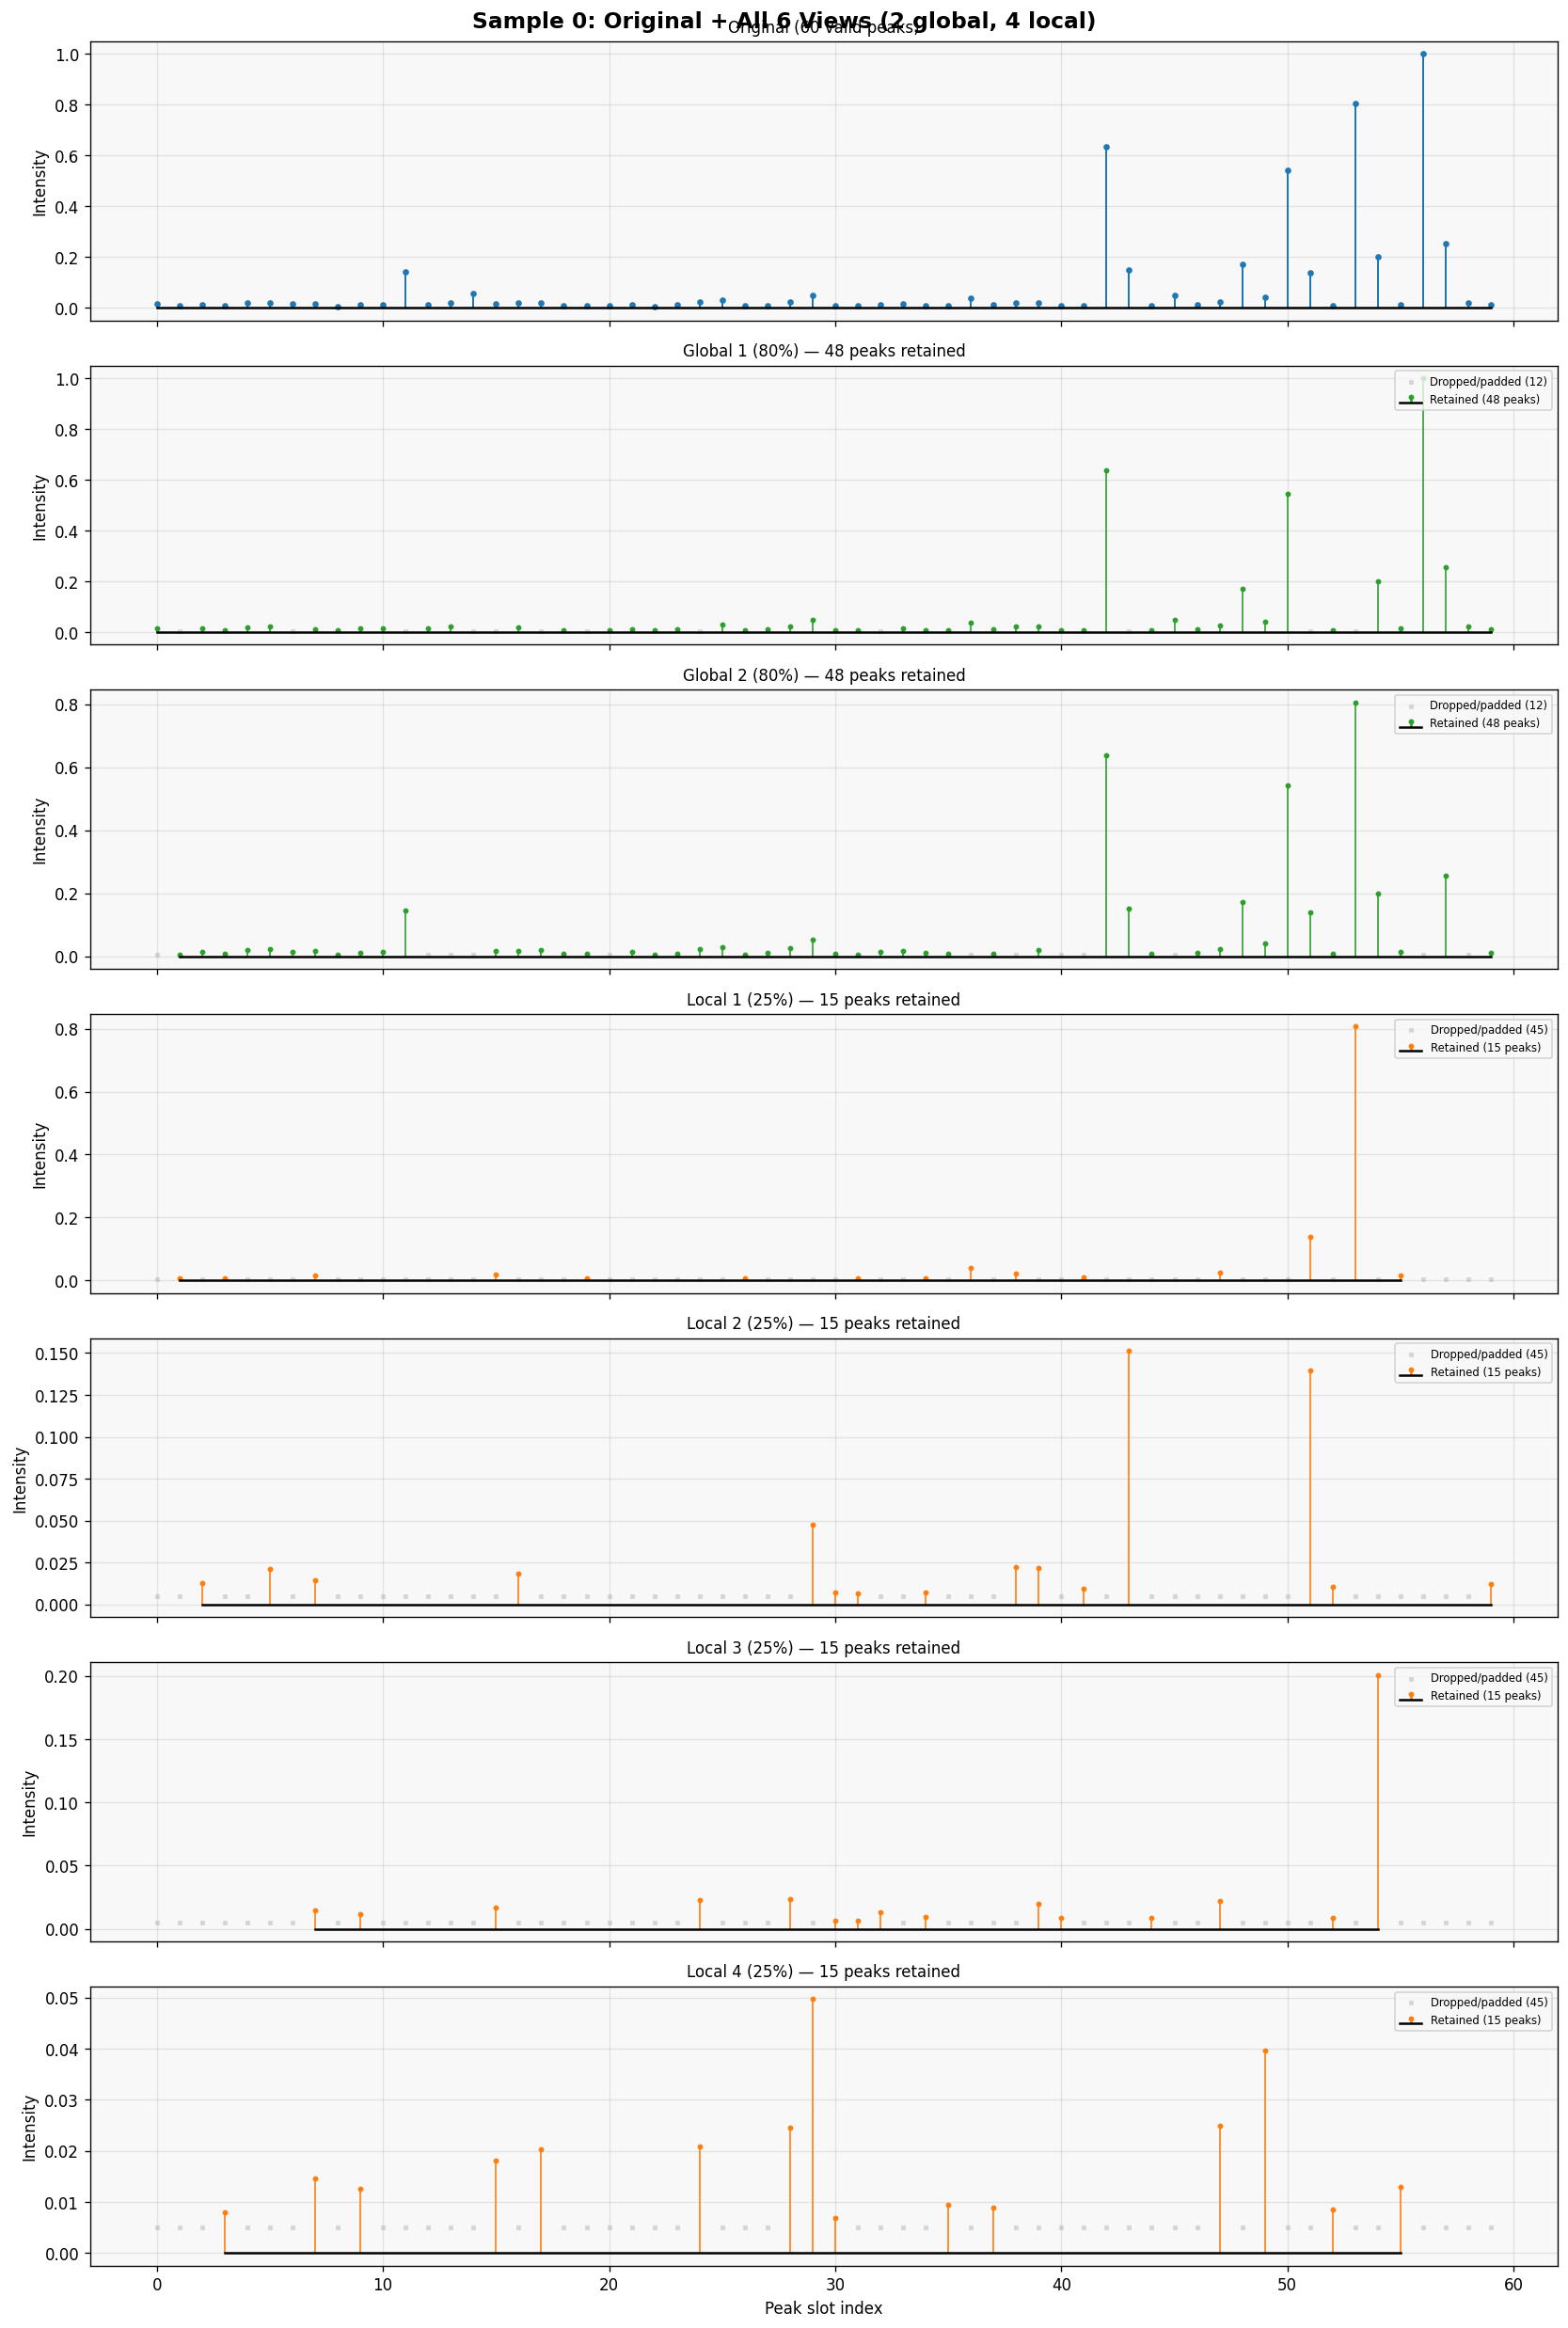

In [6]:
# Compare a single spectrum across ALL views: Original + 2 Global + 6 Local
num_global = cfg.multicrop_num_global_views
num_local = cfg.multicrop_num_local_views
V = num_global + num_local
B = 16
sample_idx = 0

orig_mz = raw_batch['peak_mz'][sample_idx]
orig_int = raw_batch['peak_intensity'][sample_idx]
orig_valid = raw_batch['peak_valid_mask'][sample_idx]

# Collect all views for this sample
views = []
for v in range(V):
    offset = v * B + sample_idx
    views.append({
        'mz': aug_batch['fused_mz'][offset],
        'int': aug_batch['fused_intensity'][offset],
        'valid': aug_batch['fused_valid_mask'][offset].astype(bool),
        'label': f'Global {v+1} (80%)' if v < num_global else f'Local {v - num_global + 1} (25%)',
        'color': 'C2' if v < num_global else 'C1',
    })

nrows = 1 + V  # original + all views
fig, axes = plt.subplots(nrows, 1, figsize=(14, 3 * nrows), sharex=True)
fig.suptitle(f'Sample {sample_idx}: Original + All {V} Views ({num_global} global, {num_local} local)',
             fontsize=14, fontweight='bold')

# Original
ax = axes[0]
v_mask = orig_valid.astype(bool)
markerline, stemlines, baseline = ax.stem(
    np.where(v_mask)[0], orig_int[v_mask],
    linefmt='C0-', markerfmt='C0o', basefmt='k-'
)
stemlines.set_linewidth(1.2)
markerline.set_markersize(3)
ax.set_ylabel('Intensity')
ax.set_title(f'Original ({v_mask.sum()} valid peaks)', fontsize=10)

# Each view
for i, view in enumerate(views):
    ax = axes[1 + i]
    v_valid = view['valid']
    v_pad = ~v_valid
    if v_valid.any():
        markerline, stemlines, baseline = ax.stem(
            np.where(v_valid)[0], view['int'][v_valid],
            linefmt=f'{view["color"]}-', markerfmt=f'{view["color"]}o', basefmt='k-',
            label=f'Retained ({v_valid.sum()} peaks)',
        )
        stemlines.set_linewidth(1.0)
        markerline.set_markersize(2.5)
    if v_pad.any():
        ax.scatter(np.where(v_pad)[0], np.full(v_pad.sum(), 0.005), c='gray', s=6,
                  marker='x', alpha=0.3, label=f'Dropped/padded ({v_pad.sum()})')
    ax.set_ylabel('Intensity')
    ax.set_title(f'{view["label"]} — {v_valid.sum()} peaks retained', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Peak slot index')

plt.tight_layout()
plt.savefig('notebooks/fig_all_views.png', bbox_inches='tight')
plt.show()

## 4. Peak Retention Heatmap

Visualize valid peak counts across all views: global views retain more peaks than local views.

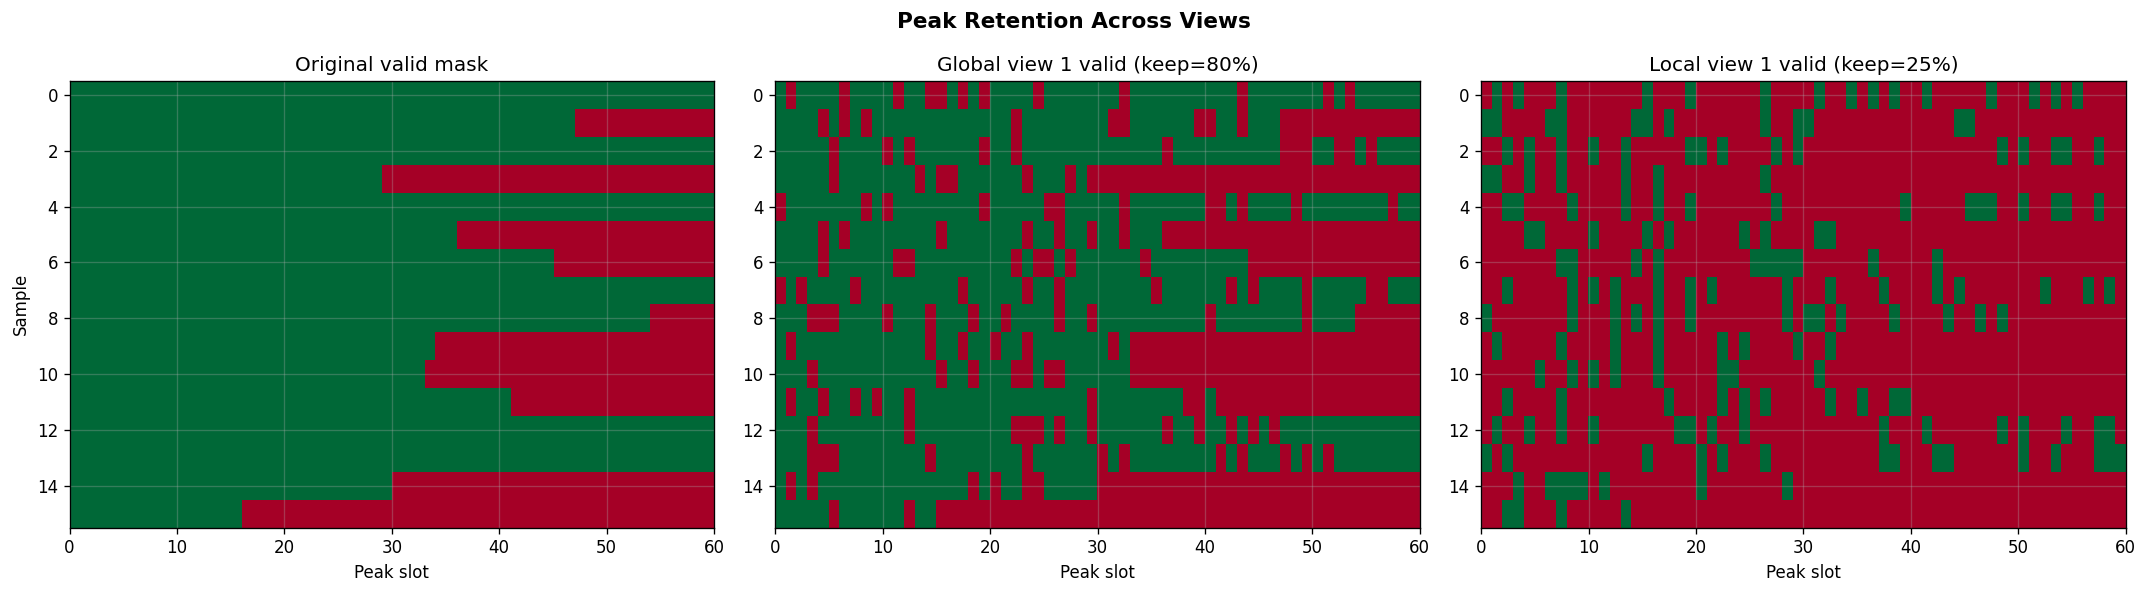

Original avg valid peaks: 45.3
Global view avg retained: 36.2 (80.0%)
Local view avg retained:  11.3 (25.0%)


In [7]:
num_global = cfg.multicrop_num_global_views
num_local = cfg.multicrop_num_local_views
V = num_global + num_local
N = _NUM_PEAKS_OUTPUT

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Peak Retention Across Views', fontsize=13, fontweight='bold')

fused_valid = aug_batch['fused_valid_mask']  # [V*B, N]
orig_valid_all = raw_batch['peak_valid_mask'][:B]

# (a) Original valid mask
ax = axes[0]
ax.imshow(orig_valid_all.astype(float), aspect='auto', cmap='RdYlGn',
          interpolation='nearest', extent=[0, N, B-0.5, -0.5])
ax.set_title('Original valid mask')
ax.set_xlabel('Peak slot')
ax.set_ylabel('Sample')

# (b) Global view valid mask (first global view)
ax = axes[1]
global_valid = fused_valid[:B]  # first global view
ax.imshow(global_valid.astype(float), aspect='auto', cmap='RdYlGn',
          interpolation='nearest', extent=[0, N, B-0.5, -0.5])
ax.set_title(f'Global view 1 valid (keep={cfg.multicrop_global_keep_fraction:.0%})')
ax.set_xlabel('Peak slot')

# (c) Local view valid mask (first local view)
ax = axes[2]
local_valid = fused_valid[num_global * B:(num_global + 1) * B]  # first local view
ax.imshow(local_valid.astype(float), aspect='auto', cmap='RdYlGn',
          interpolation='nearest', extent=[0, N, B-0.5, -0.5])
ax.set_title(f'Local view 1 valid (keep={cfg.multicrop_local_keep_fraction:.0%})')
ax.set_xlabel('Peak slot')

plt.tight_layout()
plt.savefig('notebooks/fig_retention_heatmap.png', bbox_inches='tight')
plt.show()

# Summary stats
orig_counts = orig_valid_all.sum(axis=1)
global_counts = global_valid.sum(axis=1)
local_counts = local_valid.sum(axis=1)
print(f"Original avg valid peaks: {orig_counts.mean():.1f}")
print(f"Global view avg retained: {global_counts.mean():.1f} ({global_counts.mean()/orig_counts.mean():.1%})")
print(f"Local view avg retained:  {local_counts.mean():.1f} ({local_counts.mean()/orig_counts.mean():.1%})")

## 5. Fused Batch — What the Encoder Actually Sees

The encoder receives `fused_mz` [V*B, 60], `fused_intensity` [V*B, 60], and `fused_valid_mask` [V*B, 60].
- Global view rows retain ~80% of valid peaks (more context).
- Local view rows retain ~25% of valid peaks (sparse but diverse).

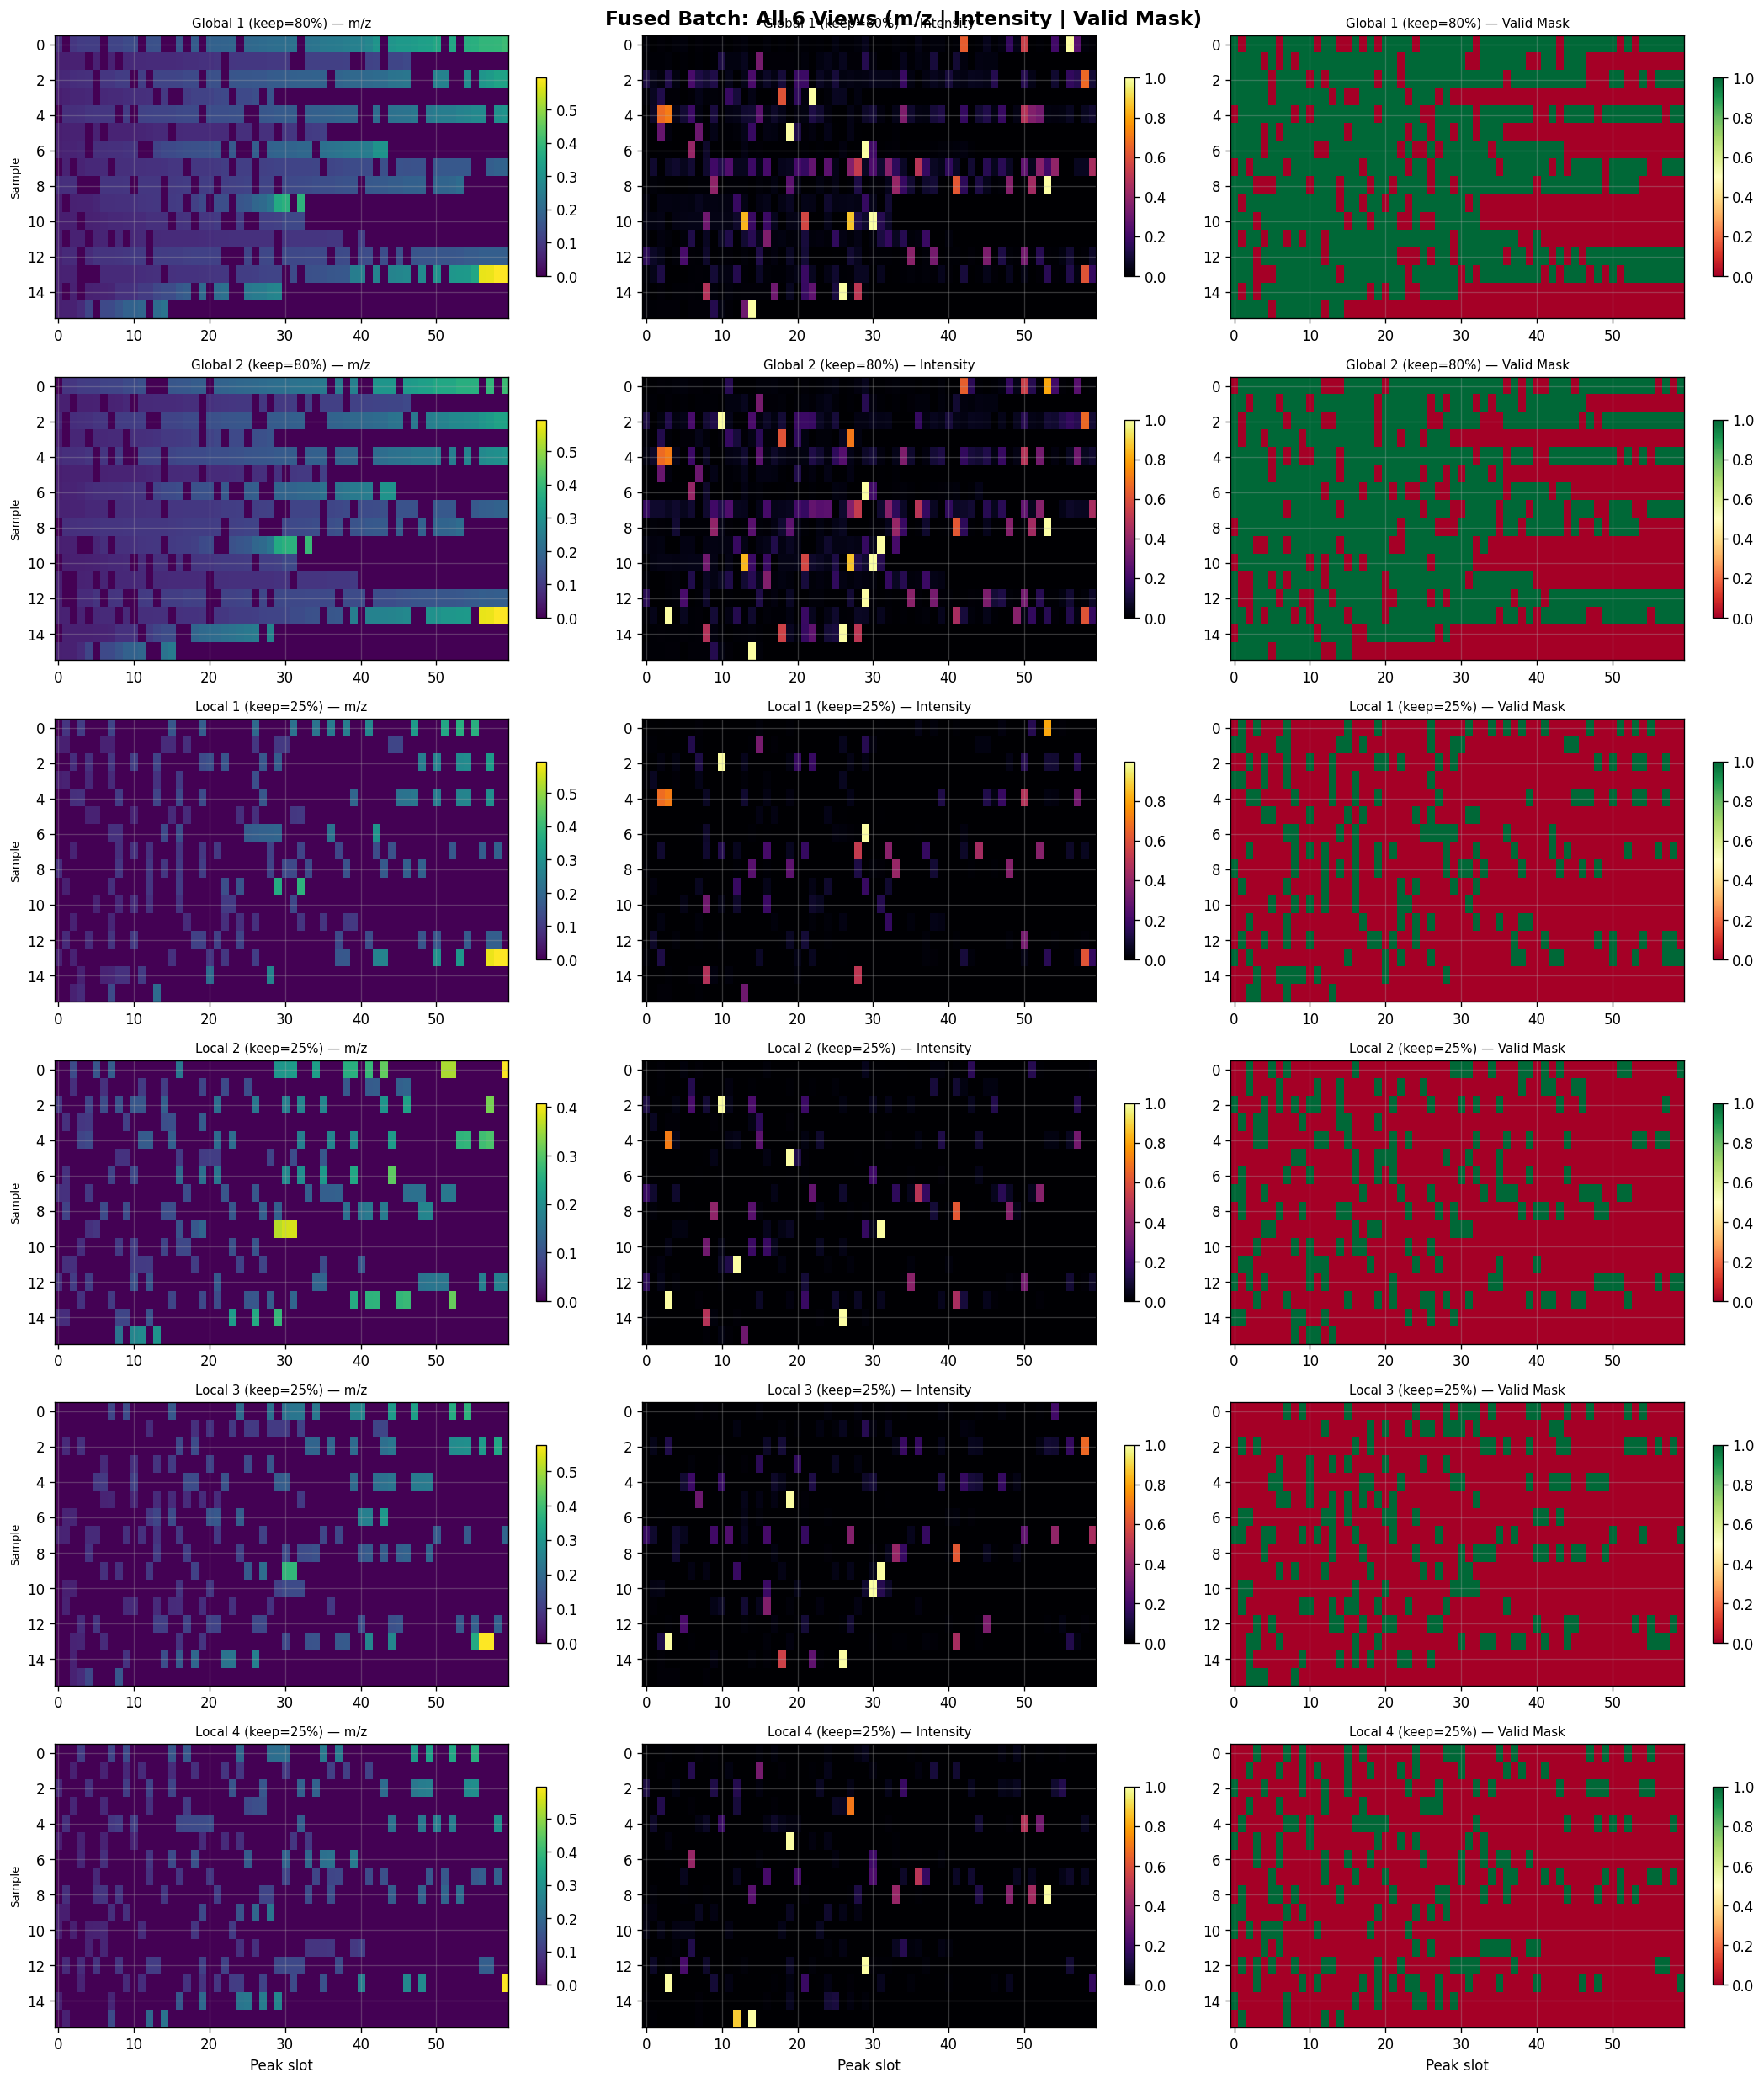

In [8]:
num_global = cfg.multicrop_num_global_views
num_local = cfg.multicrop_num_local_views
V = num_global + num_local

fused_mz = aug_batch['fused_mz']
fused_int = aug_batch['fused_intensity']
fused_valid = aug_batch['fused_valid_mask']

fig, axes = plt.subplots(V, 3, figsize=(18, 3.5 * V))
fig.suptitle(f'Fused Batch: All {V} Views (m/z | Intensity | Valid Mask)', fontsize=14, fontweight='bold')

for v in range(V):
    sl = slice(v * B, (v + 1) * B)
    if v < num_global:
        label = f'Global {v+1} (keep={cfg.multicrop_global_keep_fraction:.0%})'
    else:
        label = f'Local {v - num_global + 1} (keep={cfg.multicrop_local_keep_fraction:.0%})'

    ax = axes[v, 0]
    im = ax.imshow(fused_mz[sl], aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_title(f'{label} — m/z', fontsize=9)
    ax.set_ylabel('Sample', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7)

    ax = axes[v, 1]
    im = ax.imshow(fused_int[sl], aspect='auto', cmap='inferno', interpolation='nearest')
    ax.set_title(f'{label} — Intensity', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)

    ax = axes[v, 2]
    im = ax.imshow(fused_valid[sl].astype(float), aspect='auto', cmap='RdYlGn', interpolation='nearest')
    ax.set_title(f'{label} — Valid Mask', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)

for ax in axes[-1]:
    ax.set_xlabel('Peak slot')

plt.tight_layout()
plt.savefig('notebooks/fig_fused_batch.png', bbox_inches='tight')
plt.show()

## 6. Jitter Effect Visualization

Compare repeated augmentations for the same spectrum across global views to see jitter distribution.

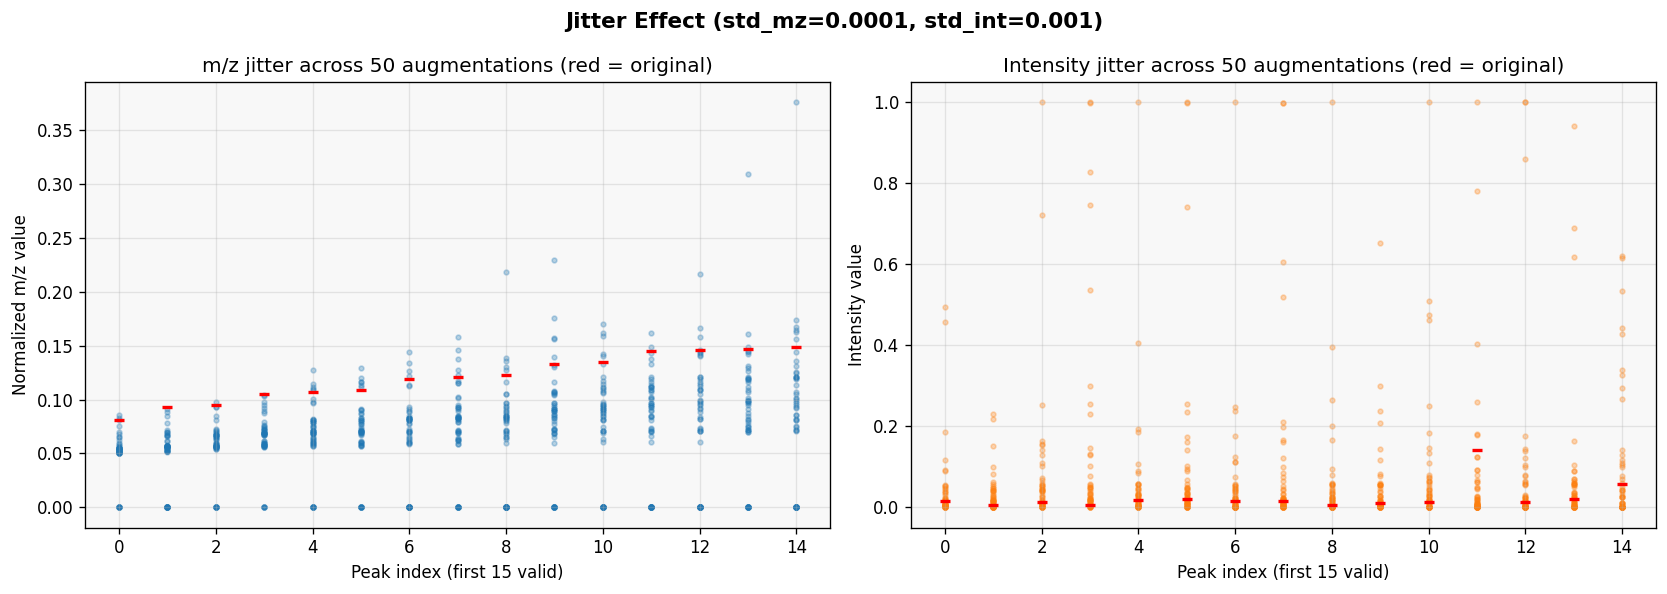

In [9]:
# Run augmentation multiple times to see jitter distribution on global view 1
n_runs = 50
sample_idx = 0

orig_mz_s = raw_batch['peak_mz'][sample_idx]
orig_int_s = raw_batch['peak_intensity'][sample_idx]
orig_valid_s = raw_batch['peak_valid_mask'][sample_idx].astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Jitter Effect (std_mz={cfg.sigreg_mz_jitter_std}, std_int={cfg.sigreg_intensity_jitter_std})',
             fontsize=13, fontweight='bold')

# Collect global view 1 from multiple augmentations
jittered_mz_all = []
jittered_int_all = []
for _ in range(n_runs):
    ab = next(aug_ds.as_numpy_iterator())
    jittered_mz_all.append(ab['fused_mz'][sample_idx])  # global view 1
    jittered_int_all.append(ab['fused_intensity'][sample_idx])

jittered_mz_all = np.stack(jittered_mz_all)
jittered_int_all = np.stack(jittered_int_all)

# m/z jitter
ax = axes[0]
valid_peaks = np.where(orig_valid_s)[0][:15]  # first 15 valid peaks
for i, pk in enumerate(valid_peaks):
    vals = jittered_mz_all[:, pk]
    orig_val = orig_mz_s[pk]
    ax.scatter(np.full_like(vals, i), vals, alpha=0.3, s=8, c='C0')
    ax.scatter(i, orig_val, c='red', s=30, marker='_', linewidths=2, zorder=5)
ax.set_xlabel('Peak index (first 15 valid)')
ax.set_ylabel('Normalized m/z value')
ax.set_title('m/z jitter across 50 augmentations (red = original)')

# Intensity jitter
ax = axes[1]
for i, pk in enumerate(valid_peaks):
    vals = jittered_int_all[:, pk]
    orig_val = orig_int_s[pk]
    ax.scatter(np.full_like(vals, i), vals, alpha=0.3, s=8, c='C1')
    ax.scatter(i, orig_val, c='red', s=30, marker='_', linewidths=2, zorder=5)
ax.set_xlabel('Peak index (first 15 valid)')
ax.set_ylabel('Intensity value')
ax.set_title('Intensity jitter across 50 augmentations (red = original)')

plt.tight_layout()
plt.savefig('notebooks/fig_jitter.png', bbox_inches='tight')
plt.show()

## 7. Fourier Features — What the Encoder Embeds

The encoder first applies `FourierFeatures` to normalized m/z values, producing a [B, N, 128] tensor of sin/cos features at log-spaced frequencies from 1 Hz to 5000 Hz.

In [10]:
import torch

# Local Fourier feature helper (matches model's 128-dim sinusoidal projection).
def ff(mz_tensor: torch.Tensor) -> torch.Tensor:
    freqs = torch.logspace(0.0, 2.0, steps=64, device=mz_tensor.device, dtype=mz_tensor.dtype)
    phases = 2.0 * torch.pi * mz_tensor.unsqueeze(-1) * freqs
    return torch.cat([torch.sin(phases), torch.cos(phases)], dim=-1)


## 8. End-to-End Single-Sample Journey

One spectrum through every pipeline stage in a single figure: raw → normalized → global view → local view → Fourier features.

/tmp/ipykernel_2697143/1938853774.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  orig_mz_torch = torch.from_numpy(o_mz[np.newaxis]).float()


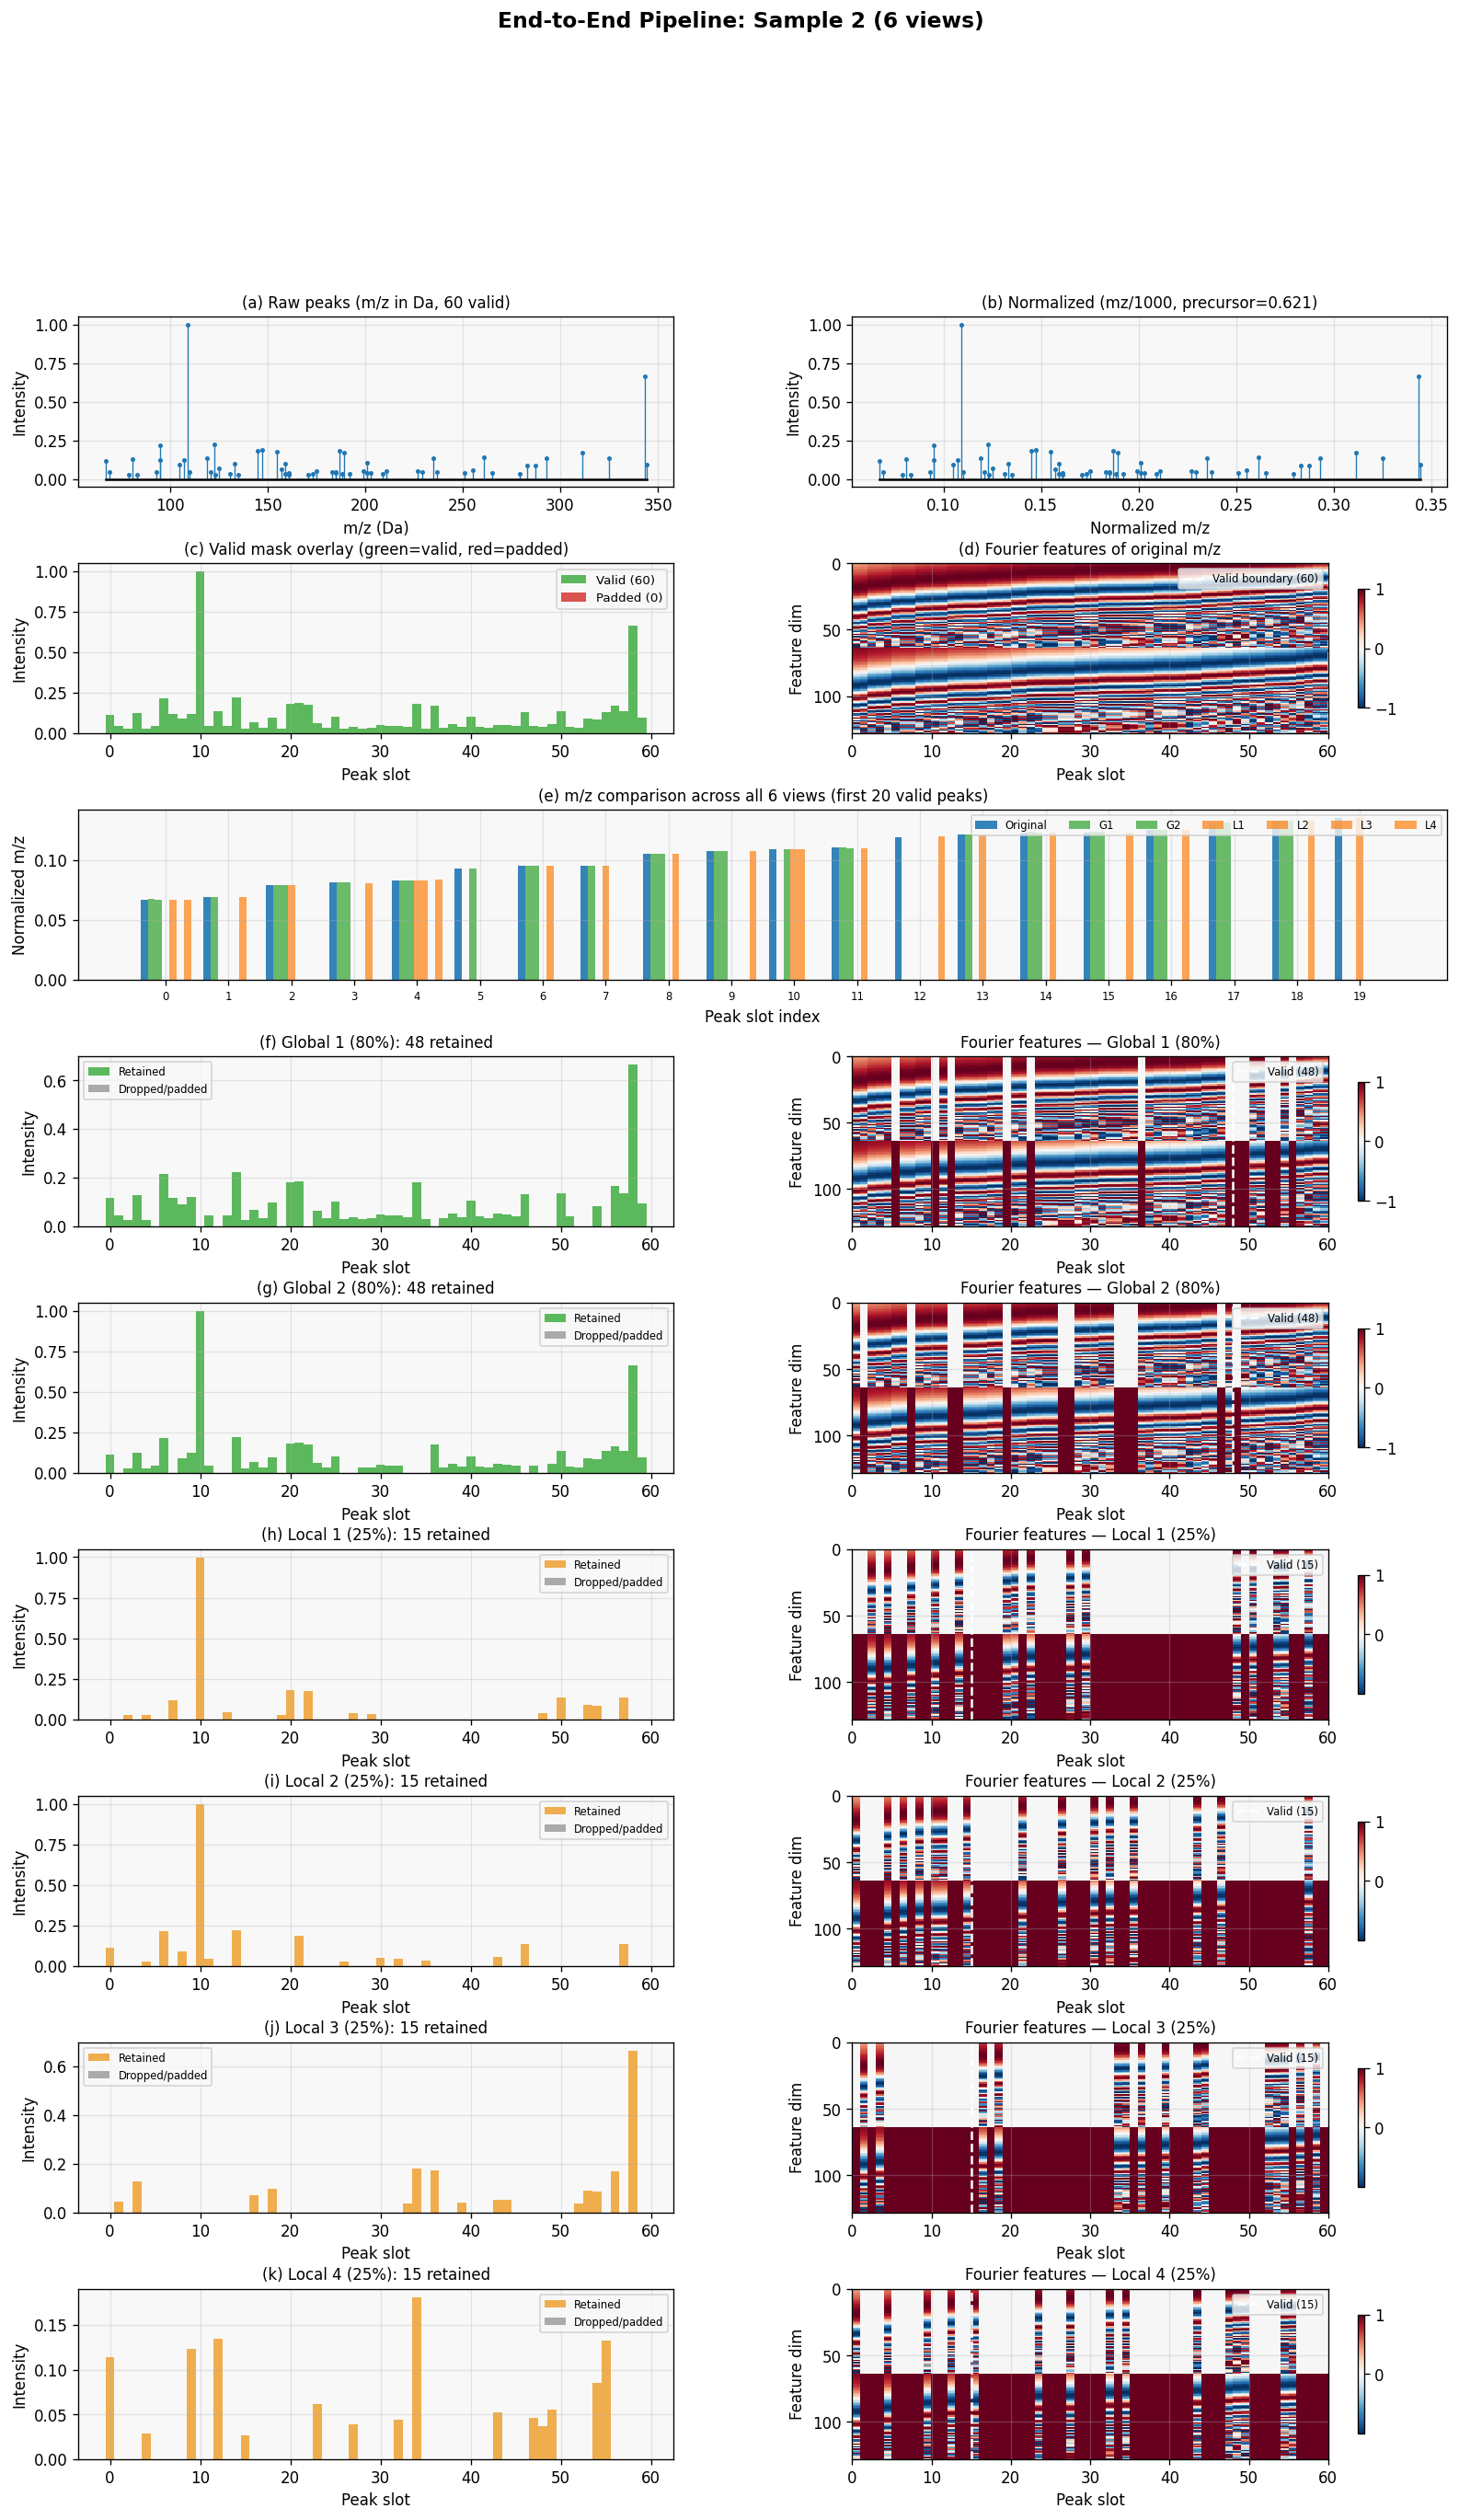

In [11]:
idx = 2
num_global = cfg.multicrop_num_global_views
num_local = cfg.multicrop_num_local_views
V = num_global + num_local

fig = plt.figure(figsize=(16, 6 + 3.2 * V))
nrows = 3 + V  # raw, normalized, valid mask, then V view rows
gs = gridspec.GridSpec(nrows, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle(f'End-to-End Pipeline: Sample {idx} ({V} views)', fontsize=14, fontweight='bold', y=0.99)

o_mz = raw_batch['peak_mz'][idx]
o_int = raw_batch['peak_intensity'][idx]
o_valid = raw_batch['peak_valid_mask'][idx].astype(bool)
o_prec = raw_batch['precursor_mz'][idx]
o_raw_mz = raw_batch['mz'][idx]
o_raw_int = raw_batch['intensity'][idx]

# (a) Raw spectrum (un-normalized)
ax = fig.add_subplot(gs[0, 0])
v_idx = np.where(o_valid)[0]
if len(v_idx) > 0:
    markerline, stemlines, baseline = ax.stem(
        o_raw_mz[v_idx], o_raw_int[v_idx],
        linefmt='C0-', markerfmt='C0o', basefmt='k-'
    )
    stemlines.set_linewidth(0.8)
    markerline.set_markersize(2)
ax.set_title(f'(a) Raw peaks (m/z in Da, {len(v_idx)} valid)', fontsize=10)
ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')

# (b) Normalized spectrum
ax = fig.add_subplot(gs[0, 1])
if len(v_idx) > 0:
    markerline, stemlines, baseline = ax.stem(
        o_mz[v_idx], o_int[v_idx],
        linefmt='C0-', markerfmt='C0o', basefmt='k-'
    )
    stemlines.set_linewidth(0.8)
    markerline.set_markersize(2)
ax.set_title(f'(b) Normalized (mz/1000, precursor={o_prec:.3f})', fontsize=10)
ax.set_xlabel('Normalized m/z')
ax.set_ylabel('Intensity')

# (c) Valid mask + padding indicator
ax = fig.add_subplot(gs[1, 0])
colors = ['#5cb85c' if v else '#d9534f' for v in o_valid]
ax.bar(range(_NUM_PEAKS_OUTPUT), o_int, color=colors, width=1.0, edgecolor='none')
ax.set_title('(c) Valid mask overlay (green=valid, red=padded)', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Intensity')
ax.legend(handles=[
    Patch(facecolor='#5cb85c', label=f'Valid ({o_valid.sum()})'),
    Patch(facecolor='#d9534f', label=f'Padded ({(~o_valid).sum()})'),
], fontsize=8)

# (d) Fourier features of original mz
ax = fig.add_subplot(gs[1, 1])
orig_mz_torch = torch.from_numpy(o_mz[np.newaxis]).float()
with torch.no_grad():
    ff_orig = ff(orig_mz_torch)[0].numpy()
im = ax.imshow(ff_orig.T, aspect='auto', cmap='RdBu_r', interpolation='nearest',
               extent=[0, _NUM_PEAKS_OUTPUT, 128, 0])
n_orig_valid = o_valid.sum()
ax.axvline(n_orig_valid, color='white', ls='--', lw=1.5, label=f'Valid boundary ({n_orig_valid})')
ax.set_title('(d) Fourier features of original m/z', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Feature dim')
ax.legend(loc='upper right', fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.7)

# (e) m/z comparison across all views (bottom row spanning full width)
ax_mz = fig.add_subplot(gs[2, :])
valid_slots = np.where(o_valid)[0][:20]
x = np.arange(len(valid_slots))
bar_width = 0.8 / (V + 1)
ax_mz.bar(x - 0.4 + bar_width / 2, o_mz[valid_slots], bar_width,
          label='Original', color='C0', alpha=0.9)
for v in range(V):
    offset = v * B + idx
    v_mz = aug_batch['fused_mz'][offset]
    if v < num_global:
        color, lbl = 'C2', f'G{v+1}'
    else:
        color, lbl = 'C1', f'L{v - num_global + 1}'
    ax_mz.bar(x - 0.4 + bar_width * (v + 1.5), v_mz[valid_slots], bar_width,
              label=lbl, color=color, alpha=0.7)
ax_mz.set_xticks(x)
ax_mz.set_xticklabels([str(s) for s in valid_slots], fontsize=7)
ax_mz.set_xlabel('Peak slot index')
ax_mz.set_ylabel('Normalized m/z')
ax_mz.set_title(f'(e) m/z comparison across all {V} views (first 20 valid peaks)', fontsize=10)
ax_mz.legend(fontsize=7, ncol=V + 1, loc='upper right')

# (f...) Each view as a bar chart
for v in range(V):
    row = 3 + v
    offset = v * B + idx
    v_int = aug_batch['fused_intensity'][offset]
    v_valid = aug_batch['fused_valid_mask'][offset].astype(bool)
    if v < num_global:
        label = f'Global {v+1} (80%)'
        bar_color = '#5cb85c'
    else:
        label = f'Local {v - num_global + 1} (25%)'
        bar_color = '#f0ad4e'

    ax = fig.add_subplot(gs[row, 0])
    view_colors = [bar_color if val else '#aaaaaa' for val in v_valid]
    ax.bar(range(_NUM_PEAKS_OUTPUT), v_int, color=view_colors, width=1.0, edgecolor='none')
    ax.set_title(f'({chr(102 + v)}) {label}: {v_valid.sum()} retained', fontsize=10)
    ax.set_xlabel('Peak slot')
    ax.set_ylabel('Intensity')
    ax.legend(handles=[
        Patch(facecolor=bar_color, label='Retained'),
        Patch(facecolor='#aaaaaa', label='Dropped/padded'),
    ], fontsize=7)

    # Fourier features of this view's mz
    ax_ff = fig.add_subplot(gs[row, 1])
    v_mz_torch = torch.from_numpy(aug_batch['fused_mz'][offset][np.newaxis]).float()
    with torch.no_grad():
        ff_v = ff(v_mz_torch)[0].numpy()
    im = ax_ff.imshow(ff_v.T, aspect='auto', cmap='RdBu_r', interpolation='nearest',
                      extent=[0, _NUM_PEAKS_OUTPUT, 128, 0])
    n_v_valid = v_valid.sum()
    ax_ff.axvline(n_v_valid, color='white', ls='--', lw=1.5, label=f'Valid ({n_v_valid})')
    ax_ff.set_title(f'Fourier features — {label}', fontsize=10)
    ax_ff.set_xlabel('Peak slot')
    ax_ff.set_ylabel('Feature dim')
    ax_ff.legend(loc='upper right', fontsize=7)
    plt.colorbar(im, ax=ax_ff, shrink=0.7)

plt.savefig('notebooks/fig_pipeline_journey.png', bbox_inches='tight')
plt.show()

## 9. Batch Statistics Summary

Aggregate statistics of the fused batch that enters the model. Shows per-view-type retention stats.

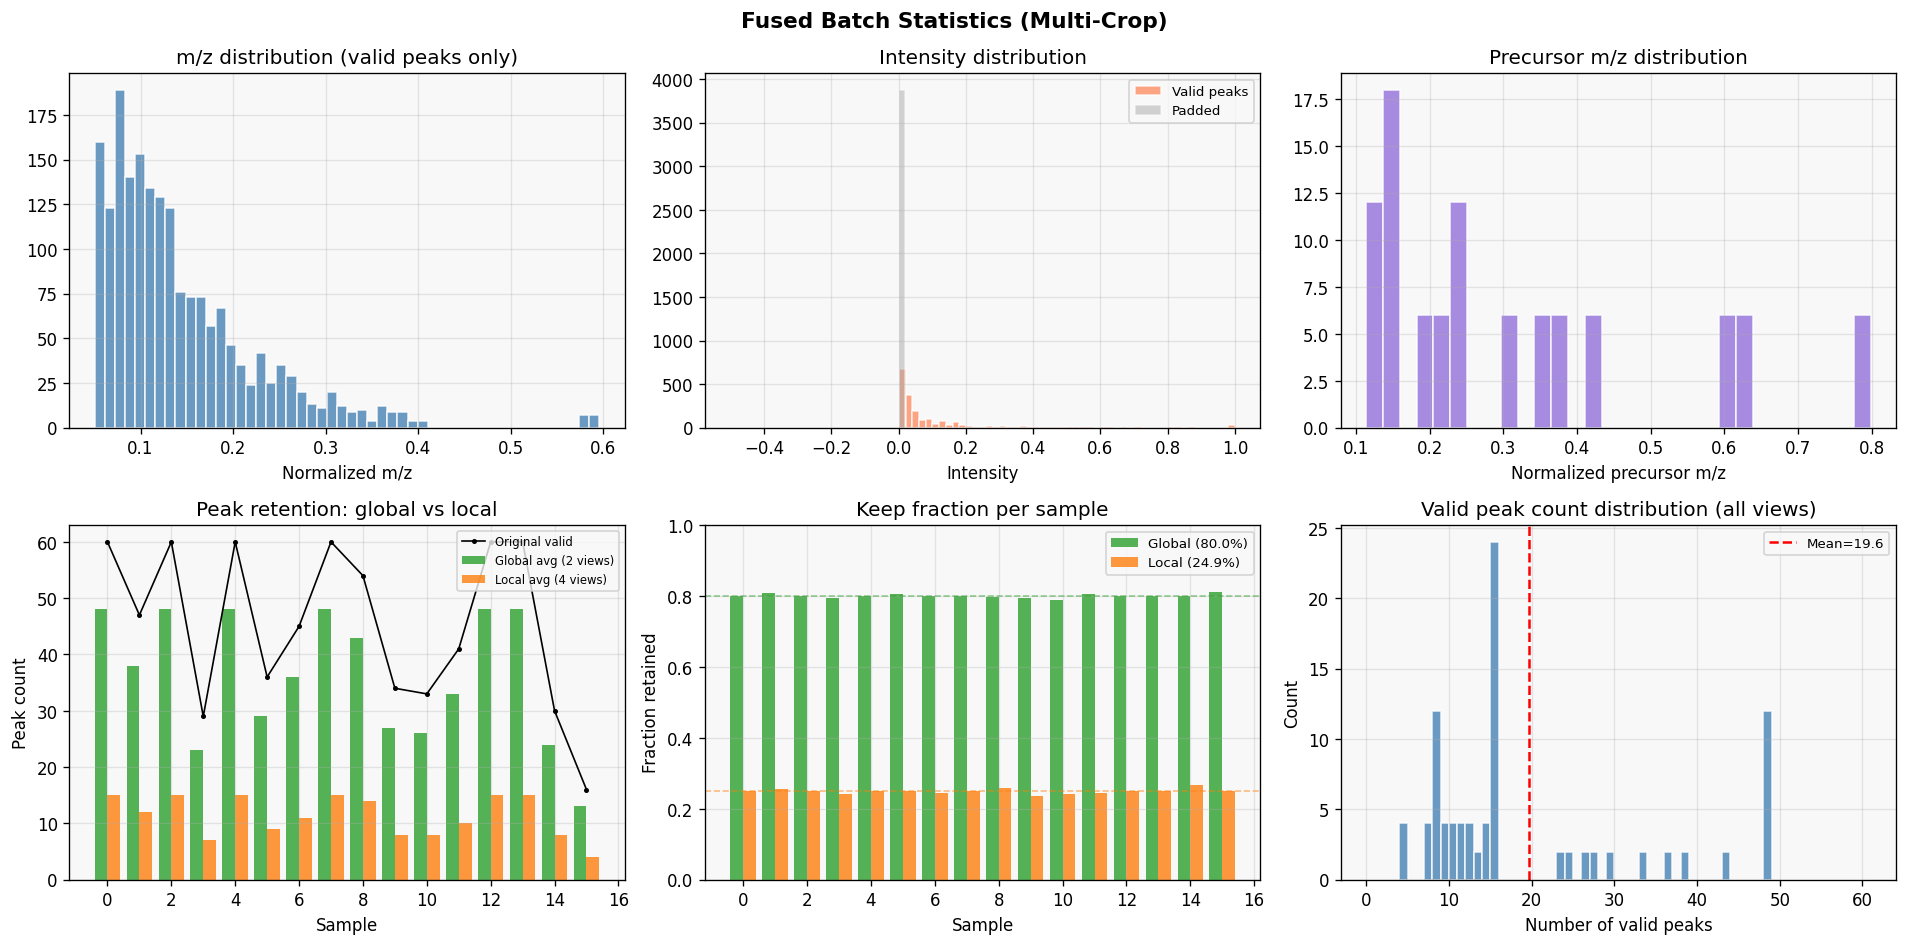


Summary:
  Batch shape: fused_mz=(96, 60), fused_intensity=(96, 60)
  V=6 views (global=2, local=4), B=16
  Encoder-visible fraction: 0.3271
  Global avg retained peaks: 36.2 / 45.3
  Local avg retained peaks:  11.3 / 45.3
  Global keep fraction: 80.0% (target 80%)
  Local keep fraction:  24.9% (target 25%)
  m/z range (valid): [0.0505, 0.5957]
  Intensity range (valid): [0.0005, 1.0000]


In [12]:
num_global = cfg.multicrop_num_global_views
num_local = cfg.multicrop_num_local_views
V = num_global + num_local

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Fused Batch Statistics (Multi-Crop)', fontsize=13, fontweight='bold')

fmz = aug_batch['fused_mz']       # [V*B, N]
fi = aug_batch['fused_intensity']
fv = aug_batch['fused_valid_mask']
fp = aug_batch['fused_precursor_mz']

# (a) m/z distribution (valid peaks only)
ax = axes[0, 0]
valid_mz = fmz[fv.astype(bool)]
ax.hist(valid_mz, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('m/z distribution (valid peaks only)')
ax.set_xlabel('Normalized m/z')

# (b) Intensity distribution: valid vs padded
ax = axes[0, 1]
valid_int = fi[fv.astype(bool)]
padded_int = fi[~fv.astype(bool)]
ax.hist(valid_int, bins=50, color='coral', edgecolor='white', alpha=0.7, label='Valid peaks')
if len(padded_int) > 0:
    ax.hist(padded_int, bins=50, color='#aaaaaa', edgecolor='white', alpha=0.5, label='Padded')
ax.set_title('Intensity distribution')
ax.set_xlabel('Intensity')
ax.legend(fontsize=8)

# (c) Precursor m/z distribution
ax = axes[0, 2]
ax.hist(fp, bins=30, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.set_title('Precursor m/z distribution')
ax.set_xlabel('Normalized precursor m/z')

# (d) Valid peak count per sample: global vs local views
ax = axes[1, 0]
global_counts = []
local_counts = []
for v in range(num_global):
    sl = slice(v * B, (v + 1) * B)
    global_counts.append(fv[sl].sum(axis=1))
for v in range(num_local):
    sl = slice((num_global + v) * B, (num_global + v + 1) * B)
    local_counts.append(fv[sl].sum(axis=1))
global_all = np.stack(global_counts)  # [num_global, B]
local_all = np.stack(local_counts)    # [num_local, B]
x = np.arange(B)
ax.bar(x - 0.2, global_all.mean(axis=0), 0.4, label=f'Global avg ({num_global} views)', color='C2', alpha=0.8)
ax.bar(x + 0.2, local_all.mean(axis=0), 0.4, label=f'Local avg ({num_local} views)', color='C1', alpha=0.8)
orig_counts = raw_batch['peak_valid_mask'][:B].sum(axis=1)
ax.plot(x, orig_counts, color='black', lw=1.0, label='Original valid', marker='.', markersize=4)
ax.set_title('Peak retention: global vs local')
ax.set_xlabel('Sample')
ax.set_ylabel('Peak count')
ax.legend(fontsize=7)

# (e) Keep fraction per sample (relative to original valid peaks)
ax = axes[1, 1]
safe_orig = np.maximum(orig_counts, 1)
global_frac = global_all.mean(axis=0) / safe_orig
local_frac = local_all.mean(axis=0) / safe_orig
ax.bar(x - 0.2, global_frac, 0.4, color='C2', alpha=0.8, label=f'Global ({global_frac.mean():.1%})')
ax.bar(x + 0.2, local_frac, 0.4, color='C1', alpha=0.8, label=f'Local ({local_frac.mean():.1%})')
ax.axhline(cfg.multicrop_global_keep_fraction, color='C2', ls='--', lw=1, alpha=0.5)
ax.axhline(cfg.multicrop_local_keep_fraction, color='C1', ls='--', lw=1, alpha=0.5)
ax.set_title('Keep fraction per sample')
ax.set_xlabel('Sample')
ax.set_ylabel('Fraction retained')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# (f) Per-view valid count distribution
ax = axes[1, 2]
all_view_counts = fv.sum(axis=1)  # [V*B]
ax.hist(all_view_counts, bins=range(0, _NUM_PEAKS_OUTPUT + 2), color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(all_view_counts.mean(), color='red', ls='--', label=f'Mean={all_view_counts.mean():.1f}')
ax.set_title('Valid peak count distribution (all views)')
ax.set_xlabel('Number of valid peaks')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_batch_stats.png', bbox_inches='tight')
plt.show()

print()
print('Summary:')
print(f"  Batch shape: fused_mz={fmz.shape}, fused_intensity={fi.shape}")
print(f"  V={V} views (global={num_global}, local={num_local}), B={B}")
print(f"  Encoder-visible fraction: {fv.mean():.4f}")
print(f"  Global avg retained peaks: {global_all.mean():.1f} / {orig_counts.mean():.1f}")
print(f"  Local avg retained peaks:  {local_all.mean():.1f} / {orig_counts.mean():.1f}")
print(f"  Global keep fraction: {global_frac.mean():.1%} (target {cfg.multicrop_global_keep_fraction:.0%})")
print(f"  Local keep fraction:  {local_frac.mean():.1%} (target {cfg.multicrop_local_keep_fraction:.0%})")
print(f"  m/z range (valid): [{valid_mz.min():.4f}, {valid_mz.max():.4f}]")
print(f"  Intensity range (valid): [{valid_int.min():.4f}, {valid_int.max():.4f}]")